## Setup

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
import numpy as np
import dataclasses

import sys
sys.path.insert(0, "../")

from fourier_prop.laser_input import (
    advanced_parameters,
    input_laser_field, 
    laser_parameters, 
    propagation_parameters,
    constants,
    utils
)

from fourier_prop.propagator import propagator
from fourier_prop.read_laser import sim_grid_parameters as grid
from fourier_prop.read_laser import read_laser
from scipy.signal import hilbert

from fourier_prop.laser_visualization import laser_visualization
cmap = np.load("../colormap.npy")
cmap = mpl.colors.ListedColormap(cmap, name='myColorMap', N=cmap.shape[0])

In [2]:
from scipy.interpolate import UnivariateSpline

def fwhm(ind_var, dep_var, percent_max=(1 / (np.exp(2))), verbose=False):
    '''Find full width at specified percentage of maximum of data
    
    Parameters
    ----------
    name (data type) [physical unit]
    
    dep_var (array) []: the data to retrieve FWHM from
    ind_var (array) []: the x-axis values
    percent_max (float) []: (default = 0.5) percentage of maximum to evaluate full width at
    
    Returns
    -------
    fwhm (float) [ind_var units]: FWHM of data in the units of the independent variable x values
    '''

    spline = UnivariateSpline(ind_var, dep_var - np.max(dep_var) * percent_max, s=0)
    if np.size(spline.roots()) == 0:
        r1 = 0
        r2 = 0
    else:
        r1 = spline.roots()[0] # find the roots
        r2 = spline.roots()[-1]
    fwhm = np.abs(r1 - r2)
    
    if verbose:
        print('Full width @ ', percent_max, '* maximum = ', fwhm)
        
    return fwhm

def gouy_phase(z, zr):
    return np.arctan2(z, zr)

def radius_of_curvature(z, zr):
    if z == 0:
        return 1e30
    return z + ((zr**2) / z)

def waist_func(waist0, z, zr):
    return waist0 * np.sqrt(1 + (z/zr)**2)

def time_envelope(fwhm, t, t_start):
    sigma = (0.5*fwhm)**2/np.log(2.0)
    return np.exp( -(t - t_start)**2 / sigma )

def get_analytic_pulse(t, y, omega, waist0, distance_from_focus, fwhm, t_start=0, y_center=0):
    lam = (2*np.pi*constants.C_UM_FS) / omega
    k = omega / constants.C_UM_FS
    zr = (np.pi * waist0**2) / lam
    waist = waist_func(waist0, distance_from_focus, zr)
    R = radius_of_curvature(distance_from_focus, zr)
    
    prop_term = np.exp(-1.0j * omega * t)
    gouy_term = np.exp(1.0j * np.arctan(distance_from_focus / zr))

    spatial_term = np.exp(-(1 / waist**2) * ((y - y_center)**2 + 0**2))
    radius_term = np.exp(-1.0j * k * ((y - y_center)**2 + 0**2) * (1 / (2 * R)))
    
    return (1 / waist) * prop_term * gouy_term * spatial_term * radius_term * time_envelope(fwhm, t, t_start) * np.exp(1.j * (np.pi) * .5)


    
def propagate_and_interpolate_field(field):
    print("Generating Input Ew Field")
    field.generate_input_Ew_field(req_low_mem = True)
    print("Generating Output Ew Field")
    propagator.generate_output_Ew_field(field)
    print("Generating Output Et Field")
    propagator.generate_output_Et_field_from_Ew(field)
    
    print("Interpolating E Field")
    read_laser.compute_field_at_sim_grid(field, utils.SingleThreadComm(), 0, 1, verbose=False)
    print("Done creating interpolated files")
    

def get_etyz_sim_and_params(field):
    sim_grid_parameters = grid.compute_sim_grid(
        field.prop.times, field.prop.y_vals_output, field.prop.z_vals_output
    )

    Etyz_sim = np.memmap(
        field.prop.data_directory_path + constants.OUTPUT_ET_SIM_FILE_Y, dtype='complex64',
        mode='r+', shape=(sim_grid_parameters.num_y_vals, sim_grid_parameters.num_t_vals, sim_grid_parameters.num_z_vals)
    )
    
    return sim_grid_parameters, Etyz_sim

In [3]:
SPATIAL_DIMENSIONS = 2
PROPAGATION_TYPE = constants.FRESNEL
MONOCHROMATIC_ASSUMPTION = True

# INPUT PLANE
Y_INPUT_RANGE = 10 * 7.5e4
Z_INPUT_RANGE = Y_INPUT_RANGE
N_Y_INPUT = (2 ** 8) + 0
N_Z_INPUT = (2 ** 8) + 0
Y_VALS_INPUT = np.linspace(-Y_INPUT_RANGE, Y_INPUT_RANGE, N_Y_INPUT)
Z_VALS_INPUT = np.linspace(-Z_INPUT_RANGE, Z_INPUT_RANGE, N_Z_INPUT)

# OUTPUT PLANE
Y_OUTPUT_RANGE = 30  # -50 to 50 um
Z_OUTPUT_RANGE = Y_OUTPUT_RANGE
N_Y_OUTPUT = (2 ** 9) + 1
N_Z_OUTPUT = (2 ** 9) + 1
Y_VALS_OUTPUT = np.linspace(-Y_OUTPUT_RANGE, Y_OUTPUT_RANGE, N_Y_OUTPUT)
Z_VALS_OUTPUT = np.linspace(-Z_OUTPUT_RANGE, Z_OUTPUT_RANGE, N_Z_OUTPUT)

# TIME DIMENSION
T_RANGE = 150
N_T = (2 ** 11) + 1

TIMES = np.linspace(-T_RANGE, T_RANGE, N_T)
TIMES -= 0.0000000001
DT = TIMES[1] - TIMES[0]
OMEGAS = np.fft.fftshift(np.fft.fftfreq(len(TIMES), DT / (2*np.pi)))
OMEGAS -= 0.00000000001

# OTHER
SAVE_DATA_AS_FILES = True
DATA_DIRECTORY_PATH = "../data_sets/"
LOW_MEM = True

In [4]:
WAVELENGTH = 1.  # um
REF_FREQ = (2*np.pi*constants.C_SPEED) / (WAVELENGTH * 1e-6)
OMEGA0 = REF_FREQ * 1e-15  # rad / PHz

POLARIZATION = constants.LINEAR_Y
SPATIAL_SHAPE = constants.GAUSSIAN
SPATIAL_GAUSSIAN_ORDER = 1
TEMPORAL_SHAPE = constants.GAUSSIAN_T
TEMPORAL_GAUSSIAN_ORDER = 1
PHASE_OFFSET = 0


WAIST_IN = 7.5e4
DELTAX = 0

USE_GRATING_EQ = False
ALPHA = 0
GRATING_SEPARATION = -29.8223114e4

PULSE_FWHM = 25.  # fs
SPOT_SIZE = 4.
OUTPUT_DISTANCE_FROM_FOCUS = 0.

NORMALIZE_TO_A0 = False
PEAK_A0 = 21.
TOTAL_ENERGY = 100000000.

# Used for LG mode
L = 1
NUM_PETALS = 4

propagation_parameters_obj = propagation_parameters.PropagationParameters(
    spatial_dimensions=SPATIAL_DIMENSIONS, propagation_type=PROPAGATION_TYPE, monochromatic_assumption=MONOCHROMATIC_ASSUMPTION, 
    y_input_range=Y_INPUT_RANGE, z_input_range=Z_INPUT_RANGE, N_y_input=N_Y_INPUT, N_z_input=N_Z_INPUT, 
    y_vals_input=Y_VALS_INPUT, z_vals_input=Z_VALS_INPUT, y_output_range=Y_OUTPUT_RANGE, z_output_range=Z_OUTPUT_RANGE,
    N_y_output=N_Y_OUTPUT, N_z_output=N_Z_OUTPUT, y_vals_output=Y_VALS_OUTPUT, z_vals_output=Z_VALS_OUTPUT,
    N_t=N_T, t_range=T_RANGE, times=TIMES, omegas=OMEGAS, save_data_as_files=SAVE_DATA_AS_FILES,
    data_directory_path=DATA_DIRECTORY_PATH, low_mem=LOW_MEM
)

laser_parameters_obj = laser_parameters.LaserParameters(
    wavelength=WAVELENGTH, ref_freq=REF_FREQ, omega0=OMEGA0, polarization=POLARIZATION,
    spatial_shape=SPATIAL_SHAPE, spatial_gaussian_order=SPATIAL_GAUSSIAN_ORDER, temporal_shape=TEMPORAL_SHAPE,
    temporal_gaussian_order=TEMPORAL_GAUSSIAN_ORDER, phase_offset=PHASE_OFFSET, use_grating_eq=USE_GRATING_EQ, alpha=ALPHA,
    grating_separation=GRATING_SEPARATION, deltax=DELTAX, pulse_fwhm=PULSE_FWHM, spot_size=SPOT_SIZE, waist_in=WAIST_IN,
    output_distance_from_focus=OUTPUT_DISTANCE_FROM_FOCUS, normalize_to_a0=NORMALIZE_TO_A0, peak_a0=PEAK_A0,
    total_energy=TOTAL_ENERGY, l=L, num_petals=NUM_PETALS
)

CENTER_PEAK_EFIELD_AT_0 = False
advanced_parameters_obj = advanced_parameters.AdvancedParameters(
    center_peak_E_at_0=CENTER_PEAK_EFIELD_AT_0,
)

## Fig. 2

In [5]:
#fig2 = "fig2/"
def get_fourier_output_difference(field, save_data=False, file_name="fourier_output_difference", plot_data=False):
    e_ty = laser_visualization.get_Et_YT(field, z_val=0, is_Ey=True, ybound=0, tbound=0, is_output=True)
    e_ty_norm = e_ty / np.abs(e_ty.real).max()
    Y_VALS, T_VALS = np.meshgrid(field.prop.y_vals_output, field.prop.times)
    analytic_pulse = get_analytic_pulse(T_VALS, Y_VALS, field.laser.omega0, field.laser.spot_size, 
                                        field.laser.output_distance_from_focus, fwhm=field.laser.pulse_fwhm*np.sqrt(2))
    analytic_pulse = analytic_pulse / np.abs(analytic_pulse.real).max()
    
    if plot_data:
        plt.figure()
        plt.imshow(analytic_pulse.real.T - e_ty_norm.real.T, aspect='auto', extent=[
            field.prop.times[-1], field.prop.times[0], field.prop.y_vals_output[0], field.prop.y_vals_output[-1]])
        plt.xlim(-50, 50)
        plt.colorbar()
        plt.title("Fourier Output Difference")
        plt.xlabel("Time [fs]")
        plt.ylabel("Y [$\\mu m$]")
        plt.show()

    #if save_data:
        #np.save(DATA_DIRECTORY_PATH + fig2 + file_name, siegman_pulse.real.T - e_ty_norm.real.T) 

def get_interpolation_output_difference(field, save_data=False, file_name="interpolation_output_difference", plot_data=False):    
    sim_grid_parameters, Etyz_sim = get_etyz_sim_and_params(field)
    
    center_y = len(Etyz_sim[:, 0, 0])//2
    center_z = len(Etyz_sim[0, 0, :])//2

    gaussian_spatial_sim = Etyz_sim[:, :, center_z]
    gaussian_spatial_sim = gaussian_spatial_sim / np.abs(gaussian_spatial_sim).max()

    times_sim = sim_grid_parameters.sim_times_fs[:sim_grid_parameters.num_t_vals]
    omegas_sim = np.fft.fftshift(np.fft.fftfreq(len(times_sim), (times_sim[1] - times_sim[0])/(2*np.pi)))
    y_sim = sim_grid_parameters.sim_y_vals_um_half[sim_grid_parameters.y_indexes.lo_index_sim_half:sim_grid_parameters.y_indexes.hi_index_sim_half + 1]

    Y_VALS_SIM, T_VALS_SIM = np.meshgrid(y_sim, times_sim)
    DT_SIM = times_sim[1] - times_sim[0]
    PHASE = np.exp(np.pi*.97925j)
    
    analytic_pulse_sim = get_analytic_pulse(T_VALS_SIM, Y_VALS_SIM, field.laser.omega0, field.laser.spot_size, 
                                        -field.laser.output_distance_from_focus, fwhm=field.laser.pulse_fwhm*np.sqrt(2), 
                                            t_start=grid.LASER_TIME_START, y_center=grid.Y_HEIGHT/2.) * PHASE

    analytic_pulse_sim = analytic_pulse_sim / np.abs(analytic_pulse_sim.real).max()
    if plot_data:
        plt.figure()
        plt.imshow(analytic_pulse_sim.real.T - gaussian_spatial_sim.real, aspect='auto', 
                   extent=[times_sim[0], times_sim[-1], y_sim[0], y_sim[-1]], 
                   interpolation="none", vmin=-.005, vmax=.005, cmap='bwr')

        FONT_SIZE = 14
        xticks = np.array([10, 30, 50, 70, 90])
        yticks = np.array([0, 5, 10, 15, 20, 25])
        plt.xticks(xticks, fontsize=FONT_SIZE)
        plt.yticks(yticks, fontsize=FONT_SIZE)
        cbar = plt.colorbar()
        cbar.ax.tick_params(labelsize=FONT_SIZE)
        plt.title("Interpolated Output Difference")
        plt.xlabel("Time [fs]")
        plt.ylabel("Y [$\\mu m$]")
        plt.show()
    
    #if save_data:
        #np.save(DATA_DIRECTORY_PATH + fig2 + file_name, analytic_pulse_sim.real.T - gaussian_spatial_sim.real) 
    return np.abs(analytic_pulse_sim.real.T - gaussian_spatial_sim.real).max()


        
def get_e_field_differences(prop_params, laser_params, advanced_params, save_data, file_names, plot_fourier_data=False, plot_interp_data=False):
    field = input_laser_field.InputField(prop_params, laser_params, advanced_params, verbose=False)
    
    propagate_and_interpolate_field(field)
    
    print("Getting Fourier Output Difference")
    get_fourier_output_difference(field, save_data=False, file_name=file_names[0], plot_data = plot_fourier_data)
    
    print("Getting Interpolation Output Difference")
    return get_interpolation_output_difference(field, save_data=save_data, file_name=file_names[1], plot_data=plot_interp_data)



Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference


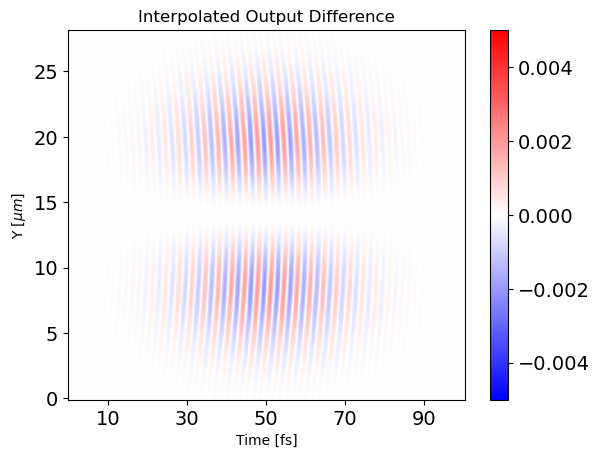

In [7]:
# Before the focus
laser_params_altered = dataclasses.replace(laser_parameters_obj)
laser_params_altered.output_distance_from_focus = -(np.pi * SPOT_SIZE**2) / WAVELENGTH
get_e_field_differences(propagation_parameters_obj, laser_params_altered, 
                        advanced_parameters_obj, save_data=True, file_names=["", "interpolated_diff_before"], plot_interp_data=True)

In [ ]:
# At the focus
laser_params_altered = dataclasses.replace(laser_parameters_obj)
laser_params_altered.output_distance_from_focus = 0
get_e_field_differences(propagation_parameters_obj, laser_params_altered, 
                        advanced_parameters_obj, save_data=True, file_names=["", "interpolated_diff_focus"], plot_interp_data=True)

In [ ]:
# After the focus
laser_params_altered = dataclasses.replace(laser_parameters_obj)
laser_params_altered.output_distance_from_focus = (np.pi * SPOT_SIZE**2) / WAVELENGTH
get_e_field_differences(propagation_parameters_obj, laser_params_altered, 
                        advanced_parameters_obj, save_data=True, file_names=["", "interpolated_diff_after"], plot_interp_data=True)

### New Figure

In [38]:
# Before the focus, higher res
num_pts = np.array([(2**5) + 1, (2**6) + 1, (2**7) + 1, (2**8) + 1, (2**9) + 1])
laser_params_altered = dataclasses.replace(laser_parameters_obj)
laser_params_altered.output_distance_from_focus = -(np.pi * SPOT_SIZE**2) / WAVELENGTH

diff_vals_before = np.zeros((num_pts.size))

for i, pts in enumerate(num_pts):
    prop_params_altered = dataclasses.replace(propagation_parameters_obj)
    prop_params_altered.N_y_output = pts
    prop_params_altered.N_y_output = pts

    prop_params_altered.y_vals_output = np.linspace(-prop_params_altered.y_output_range, prop_params_altered.y_output_range, prop_params_altered.N_y_output)
    prop_params_altered.z_vals_output = np.linspace(-prop_params_altered.z_output_range, prop_params_altered.z_output_range, prop_params_altered.N_z_output)

    max_diff = get_e_field_differences(prop_params_altered, laser_params_altered, 
                        advanced_parameters_obj, save_data=True, file_names=["", "interpolated_diff_before"])
    diff_vals_before[i] = max_diff

Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Differ

In [44]:
# At the focus, higher res
num_pts = np.array([(2**5) + 1, (2**6) + 1, (2**7) + 1, (2**8) + 1, (2**9) + 1])
laser_params_altered = dataclasses.replace(laser_parameters_obj)
laser_params_altered.output_distance_from_focus = 0

diff_vals_focus = np.zeros((num_pts.size))

for i, pts in enumerate(num_pts):
    prop_params_altered = dataclasses.replace(propagation_parameters_obj)
    prop_params_altered.N_y_output = pts
    prop_params_altered.N_y_output = pts

    prop_params_altered.y_vals_output = np.linspace(-prop_params_altered.y_output_range, prop_params_altered.y_output_range, prop_params_altered.N_y_output)
    prop_params_altered.z_vals_output = np.linspace(-prop_params_altered.z_output_range, prop_params_altered.z_output_range, prop_params_altered.N_z_output)

    max_diff = get_e_field_differences(prop_params_altered, laser_params_altered, 
                        advanced_parameters_obj, save_data=True, file_names=["", "interpolated_diff_focus"])
    diff_vals_focus[i] = max_diff

Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Differ

In [45]:
# After the focus, higher res
num_pts = np.array([(2**5) + 1, (2**6) + 1, (2**7) + 1, (2**8) + 1, (2**9) + 1])
laser_params_altered = dataclasses.replace(laser_parameters_obj)
laser_params_altered.output_distance_from_focus = (np.pi * SPOT_SIZE**2) / WAVELENGTH

diff_vals_after = np.zeros((num_pts.size))

for i, pts in enumerate(num_pts):
    prop_params_altered = dataclasses.replace(propagation_parameters_obj)
    prop_params_altered.N_y_output = pts
    prop_params_altered.N_y_output = pts

    prop_params_altered.y_vals_output = np.linspace(-prop_params_altered.y_output_range, prop_params_altered.y_output_range, prop_params_altered.N_y_output)
    prop_params_altered.z_vals_output = np.linspace(-prop_params_altered.z_output_range, prop_params_altered.z_output_range, prop_params_altered.N_z_output)

    max_diff = get_e_field_differences(prop_params_altered, laser_params_altered, 
                        advanced_parameters_obj, save_data=True, file_names=["", "interpolated_diff_after"])
    diff_vals_after[i] = max_diff

Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Difference
Getting Interpolation Output Difference
Generating Input Ew Field
Generating Output Ew Field
Generating Output Et Field
Interpolating E Field
Done creating interpolated files
Getting Fourier Output Differ

[0.03231988 0.01612392 0.00808379 0.00404312 0.00324927]
[0.02311127 0.01145245 0.00572843 0.00286779 0.00143555]
[0.03231988 0.01612392 0.00808379 0.00404312 0.00324927]
[0.03231988 0.01612392 0.00808379 0.00404312 0.00324927]


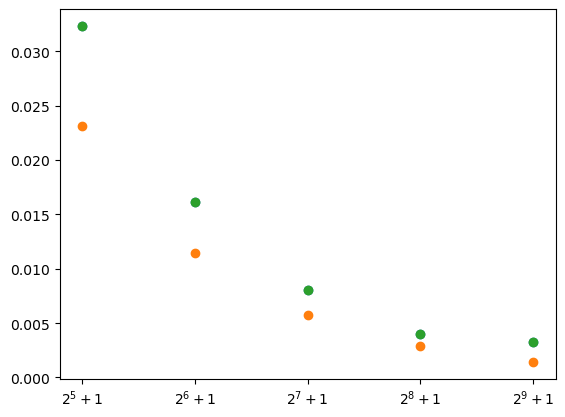

In [53]:
#print(diff_vals_before)
diff_vals_max = np.maximum(diff_vals_before, diff_vals_focus, diff_vals_after)
#diff_vals_max = np.maximum(diff_vals_max, diff_vals_after)

#plt.scatter(num_pts, diff_vals_before * 100)
plt.scatter(np.array(["$2^5 + 1$", "$2^6 + 1$", "$2^7 + 1$", "$2^8 + 1$", "$2^9 + 1$"]), diff_vals_before)
plt.scatter(np.array(["$2^5 + 1$", "$2^6 + 1$", "$2^7 + 1$", "$2^8 + 1$", "$2^9 + 1$"]), diff_vals_focus)
plt.scatter(np.array(["$2^5 + 1$", "$2^6 + 1$", "$2^7 + 1$", "$2^8 + 1$", "$2^9 + 1$"]), diff_vals_after)
#plt.xlim(300, 510)
#plt.xticks(num_pts)
#plt.yscale('log')
#plt.xscale('log')

print(diff_vals_before)
print(diff_vals_focus)
print(diff_vals_after)
print(diff_vals_max)

In [54]:
REVISION_DATA_PATH = "/Users/kylecharbonnet/revision_data/"

np.save(REVISION_DATA_PATH + "mono_diff_res_fourier", diff_vals_max)

In [56]:
mono_diff_fourier = np.load(REVISION_DATA_PATH + "mono_diff_res_fourier.npy")
mono_diff_sims = np.load(REVISION_DATA_PATH + "simulation_output_resolution_diffs.npy")

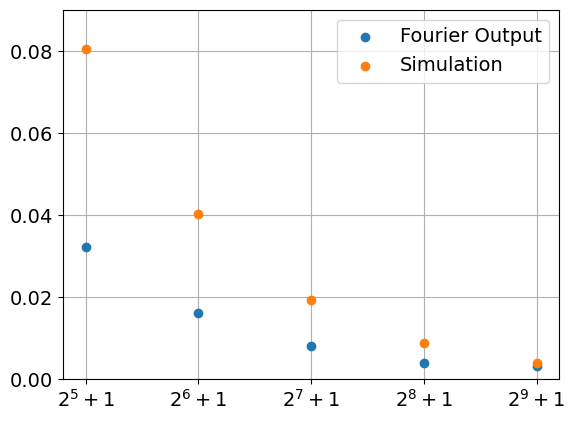

In [87]:
xticks = np.array(["$2^5 + 1$", "$2^6 + 1$", "$2^7 + 1$", "$2^8 + 1$", "$2^9 + 1$"])
plt.scatter(xticks, mono_diff_fourier, label='Fourier Output', zorder=2)
plt.scatter(xticks, mono_diff_sims, label='Simulation', zorder=2)

FONT_SIZE = 14
yticks = np.array([0, 0.02, .04, .06, .08])
plt.ylim(0, .09)
plt.xticks(xticks, fontsize=FONT_SIZE)
plt.yticks(yticks, fontsize=FONT_SIZE)
#plt.title("Interpolated Output Difference")
#plt.xlabel("Time [fs]")
#plt.ylabel("Y [$\\mu m$]")
plt.grid(which='both', axis='both', zorder=1.0)
plt.legend(prop={'size': FONT_SIZE})
#plt.show()

#plt.savefig(REVISION_DATA_PATH + "resolution_diff", transparent=True)